In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import defaultdict
random.seed(27)

In [2]:
class racetrack_map:
    def __init__(self):
        self.grid = np.zeros((5, 5))
        self.rows = self.grid.shape[0]
        self.cols = self.grid.shape[1]
    #   0: wall, 1: track, 2: start, 3: finish
    # This is a 5x5 simple racetrack map
    def create_map(self):
        for row in range(0, 5):
            for col in range(2, 4):
                self.grid[row, col] = 1
        for row in range(0, 2):
            for col in range(2, 5):
                self.grid[row, col] = 1

        #starting line
        for col in range(2, 4):
            self.grid[4, col] = 2

        #finish line
        for row in range(0, 2):
            self.grid[row, 4] = 3

        return self.grid
    
        
    def print_track(self, trajectories=None):
        cmap = mcolors.ListedColormap(['white', 'lightgray', 'salmon', 'lightgreen'])
        plt.figure(figsize=(6, 8))
        plt.imshow(self.grid, cmap=cmap, origin='upper')

        for i in range(self.rows):
            plt.axhline(i - 0.5, color='black', linewidth=0.5)
        for j in range(self.cols):
            plt.axvline(j - 0.5, color='black', linewidth=0.5)

        if trajectories is not None:
            for trajectory in trajectories:
                ys = [s[0] for s in trajectory]
                xs = [s[1] for s in trajectory]
                plt.plot(xs, ys, 'ro-', markersize=2, linewidth=1.0, alpha=0.7)
                plt.plot(xs[0], ys[0], 'bo', markersize=5)  # start
                plt.plot(xs[-1], ys[-1], 'go', markersize=5)  # end
                
        plt.axis('off')
        plt.tight_layout()
        plt.show()


In [3]:
# # defining the agent
# class car:
#     def __init__(self,x, y, vx, vy, ax, ay):
#         self.x, self.y = x, y

In [4]:
# agent and environment
class racetrack:
    def __init__(self, map, noise=0.1):
        self.noise = noise
        self.map = map
        self.state = None
        self.actions = [(1, -1), (1, 0), (1, 1), 
                        (0, -1), (0, 0), (0, 1),
                        (-1, -1), (-1, 0), (-1, 1)]
        self.rows = self.map.shape[0]
        self.cols = self.map.shape[1]
        self.start_cells = [[r,c] for r in range(self.rows) for c in range(self.cols) if self.map[r,c] == 2]
        self.finish_cells = [[r,c] for r in range(self.rows) for c in range(self.cols) if self.map[r,c] == 3]

    def start_location(self):
        return random.choice(self.start_cells)

    def reset(self):
        self.state = (self.start_location()[0],self.start_location()[1], 0, 0)
        return self.state
    
    def step(self, action):

        reward = 0
        finished = False
        # vx is the velocity in row direction, vy is the velocity in column direction
        row, col, vx, vy = self.state
        ax, ay = action

        # # add noise to the action
        # if random.random() < self.noise:
        #     ax, ay = 0, 0
    
        # update velocity
        vx += ax 
        vy += ay
        vx = max(-4, min(vx, 4))
        vy = max(0, min(vy, 4))

        # update position
        row += vx
        col += vy

        # if car stop before the finish line, it will be reset to the starting line
        # if vx == 0 and vy == 0 and self.map[row, col] != 3:
        #     row, col = self.start_location()

        # update state
        self.state = (row, col, vx, vy)

        # check if the car is out of the map
        if row < 0 or row >= self.rows or col < 0 or col >= self.cols or self.map[row, col] == 0:
            row, col = self.start_location()
            reward = -100
            self.state = (row, col, 0, 0)
            return self.state, reward, finished
        
        # check if the car is on the finish line
        if self.map[row, col] == 3:
            reward = 1000
            finished = True
            return self.state, reward, finished
        
        reward = -1
        return self.state, reward, finished
        


In [5]:
def generate_possible_actions(state, actions, noise=0.1):
    p_actions = []
    for a in actions:
        if state[2] + a[0] == 0 and state[3] + a[1] == 0:
            continue
        p_actions.append(a)

    # if random.random() < noise:
    #     actions.append((0, 0))
    return p_actions

In [6]:
# run the game

def gameplay(env, policy=None, max_steps=2000):
    trajectory = []
    total_reward = 0
    finished = False
    state = env.reset()

    for _ in range(max_steps):
        
        trajectory.append(state)
        if policy and state in policy:
            action = policy[state]
            if random.random() < env.noise:
                action = (0, 0)
        else:
            select_actions = generate_possible_actions(state, env.actions, env.noise)
            if len(select_actions) == 0:
                finished = True
                break
            else:    
                if random.random() < env.noise:
                    action = (0, 0)
                else: action = random.choice(select_actions)
        
        state, reward, finish = env.step(action)
        total_reward += reward
        finished = finish
        if finished:
            trajectory.append(state)
            break
        
    return trajectory, total_reward
        



In [7]:
# Monte Carlo Control

def on_policy_MC_ctrl(env, episodes = 2000,  gamma = 0.9, epsilon = 0.1, max_steps = 1000):
    q_table = defaultdict(lambda: defaultdict(float))
    num_returns = defaultdict(lambda: defaultdict(int))
    policy = {}
    
    reward_ep = []
    success = []
    suc_count = 0

    def epsilon_greedy_policy(state):
        select_actions = generate_possible_actions(state, env.actions)
        if not select_actions:
            return (0, 0)
        if state not in policy:
            policy[state] = random.choice(select_actions)

        if random.random() < epsilon:
            return random.choice(select_actions)
        else:
            return policy[state]
        
    for e in range(episodes):
        ep_states = []
        ep_actions = []
        ep_rewards = []

        state = env.reset()
        finished = False
        #loop
        for _ in range(max_steps):
            action = epsilon_greedy_policy(state)
            ep_states.append(state)
            ep_actions.append(action)
            next_state, reward, finished = env.step(action)
            ep_rewards.append(reward)
            
            state = next_state
            if finished:
                suc_count += 1
                success.append(1)
                break
            success.append(0)
        reward_ep.append(sum(ep_rewards))

        # update q_table
        G = 0
        visited_states = set()
        for t in reversed(range(len(ep_states))):
            state = ep_states[t]
            action = ep_actions[t]
            reward = ep_rewards[t]
            G = gamma * G + reward
            if (state, action) not in visited_states:
                visited_states.add((state, action))
                num_returns[state][action] += 1
                q_table[state][action] += (G - q_table[state][action]) / num_returns[state][action]

                policy[state] = max(q_table[state], key=q_table[state].get)

        if e % 10000 == 0:
            print(f"Episode {e}/{episodes}, Total Reward: {sum(ep_rewards)}")
                
    return policy, q_table, reward_ep, success

In [8]:
def mc_off_policy_control(env, num_episodes=2000, gamma=0.9, max_steps=1000):
    Q = defaultdict(lambda: defaultdict(float))
    C = defaultdict(lambda: defaultdict(float))
    target_policy = {}

    # 行为策略：随机 (ar<=0, ac>=0)
    def behavior_policy(_s):
        acts = []
        for ar in [-1, 0, 1]:
            for ac in [-1, 0, 1]:
                if ar <= 0 and ac >= 0:
                    acts.append((ar, ac))
        return random.choice(acts)

    for _ in range(num_episodes):
        episode_states = []
        episode_actions = []
        episode_rewards = []

        s = env.reset()
        for _2 in range(max_steps):
            a = behavior_policy(s)
            episode_states.append(s)
            episode_actions.append(a)
            s_next, r_next, done = env.step(a)
            episode_rewards.append(r_next)
            s = s_next
            if done:
                break

        G = 0
        W = 1.0
        visited_sa = set()
        for t in reversed(range(len(episode_states))):
            st = episode_states[t]
            at = episode_actions[t]
            rt = episode_rewards[t]
            G = gamma * G + rt

            if (st, at) not in visited_sa:
                visited_sa.add((st, at))
                C[st][at] += W
                Q[st][at] += (W / C[st][at]) * (G - Q[st][at])

                # 贪心选动作
                best_a = max(Q[st], key=Q[st].get)
                target_policy[st] = best_a

                if at != best_a:
                    break

            # 行为策略9种动作，概率1/9
            W *= 1 / (1/9)

    return target_policy, Q


In [9]:
def plot_training_curve(episode_rewards):
    plt.figure(figsize=(10,5))
    
    
    episodes = np.arange(1, len(episode_rewards) + 1)
    rewards = np.array(episode_rewards)

   
    plt.plot(episodes, rewards, label="Training Reward", alpha=0.7, linewidth=1, color='orange')
    
  
    # smoothed_rewards = np.convolve(rewards, np.ones(100)/100, mode='valid')
    # plt.plot(episodes[:len(smoothed_rewards)], smoothed_rewards, label="Smoothed Reward (Moving Avg)", linewidth=2, color='red')

   
    plt.xscale("log")
    
    plt.xlabel("Episodes (log scale)")
    plt.ylabel("Rewards")
    plt.title("Training Reward Curve")
    plt.legend()
    plt.grid()
    plt.show()

# def plot_success_rate(success_ep, window=100):
#     success_rate = np.convolve(success_ep, np.ones(window)/window, mode='valid')  # Moving average
#     plt.figure(figsize=(10, 5))
#     plt.plot(success_rate * 100, label="Success Rate (Moving Avg)", color="blue")
#     plt.xlabel("Episodes")
#     plt.ylabel("Success Rate (%)")
#     plt.title("Success Rate Over Training Episodes")
#     plt.legend()
#     plt.grid()
#     plt.show()



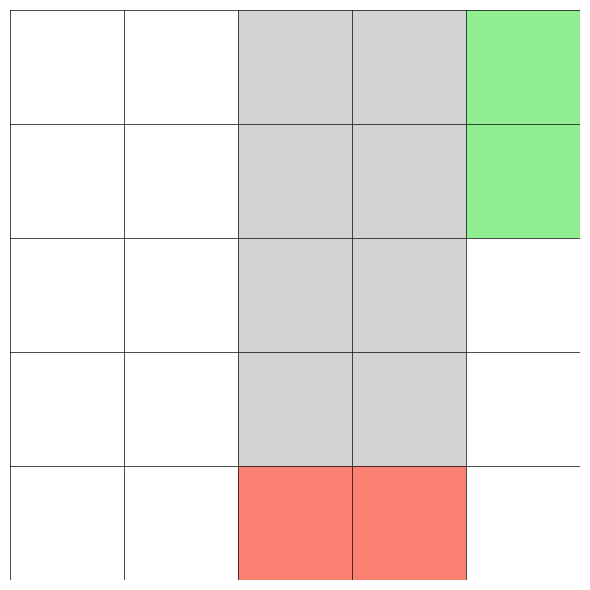

On-Policy MC Control...
Episode 0/5000, Total Reward: 592
   on_policy size = 24
3) Off-Policy MC Control...
   off_policy size = 21
Testing on_policy:
   Steps=3, Reward=999, FinalPos=(1, 4, -2, 1)
Trajectory: [(4, 3, 0, 0), (3, 3, -1, 0), (1, 4, -2, 1)]
Testing off_policy:
   Steps=3, Reward=999, FinalPos=(1, 4, -2, 1)
Trajectory: [(4, 3, 0, 0), (3, 3, -1, 0), (1, 4, -2, 1)]


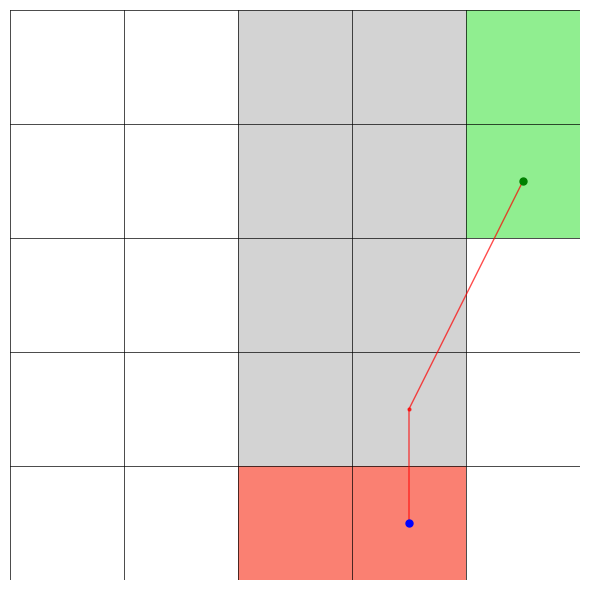

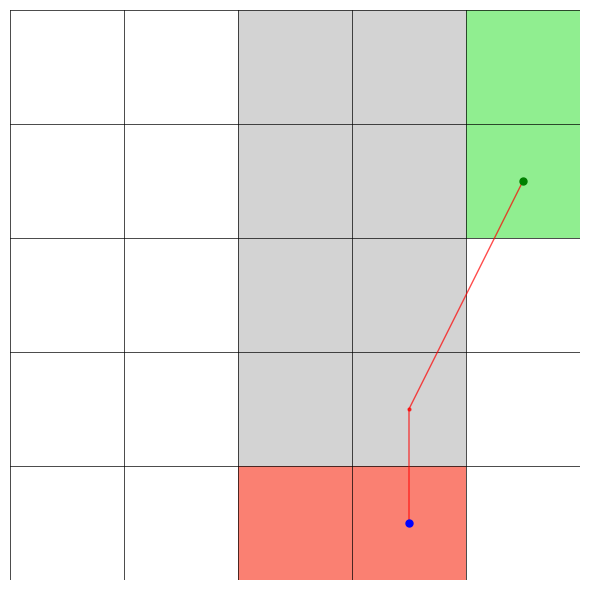

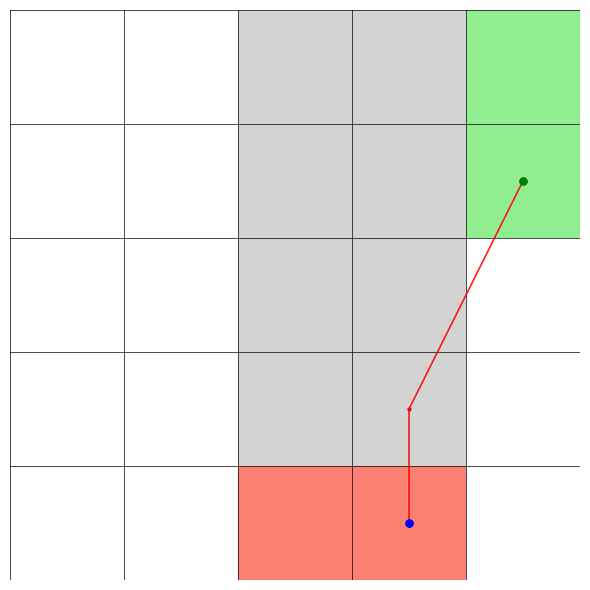

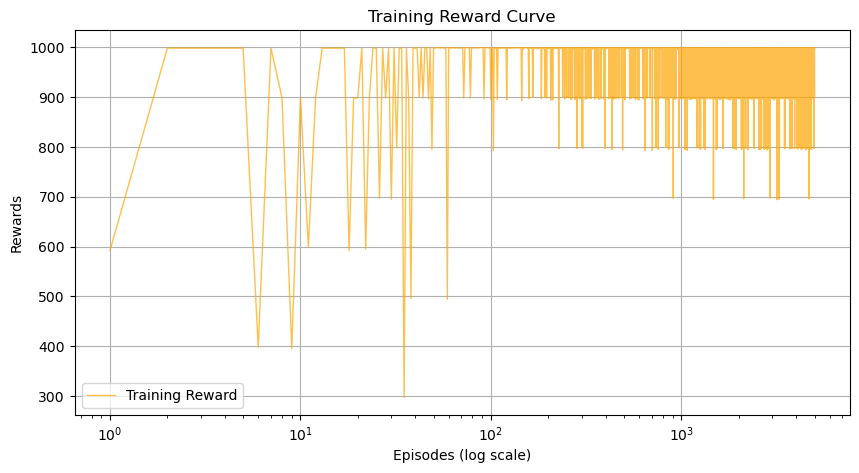

In [10]:
# test
game = racetrack_map()
game.create_map()
game.print_track()
env = racetrack(game.grid, noise=0.1)

print("On-Policy MC Control...")
on_policy, q_on, ep_r, _  = on_policy_MC_ctrl(env, episodes=5000, gamma=0.9, epsilon=0.1)
print("   on_policy size =", len(on_policy))

print("3) Off-Policy MC Control...")
off_policy, Q_off = mc_off_policy_control(env, num_episodes=5000)
print("   off_policy size =", len(off_policy))



# print trajectory
print("Testing on_policy:")
trajectory, total_reward = gameplay(env, on_policy, max_steps=2000)
print(f"   Steps={len(trajectory)}, Reward={total_reward}, FinalPos={trajectory[-1]}")

print( "Trajectory:", trajectory)

print("Testing off_policy:")
traj_off, r_off = gameplay(env, off_policy, max_steps=2000)
print(f"   Steps={len(traj_off)}, Reward={r_off}, FinalPos={traj_off[-1]}")

print("Trajectory:", traj_off)

game.print_track([trajectory])
game.print_track([traj_off])
game.print_track([trajectory, traj_off])

#rewards curve
plot_training_curve(ep_r)


# Try more maps


In [11]:
class racetrack_map_1:
    def __init__(self):
        # the map from textbook 32x16 grid
        self.grid = np.zeros((32, 16))
        self.rows = self.grid.shape[0]
        self.cols = self.grid.shape[1]

    def create_map(self):
        # add track upper part
        for row in range(0, 6):
            for col in range(3, self.cols):
                self.grid[row, col] = 1
        for row in range(1, 3):
            for col in range(2, self.cols):
                self.grid[row, col] = 1
        for row in range(3, 4):
            for col in range(1, self.cols):
                self.grid[row, col] = 1
        for row in range(4, 6):
            for col in range(0, self.cols):
                self.grid[row, col] = 1
        for row in range(6, 7):
            for col in range(0, 11):
                self.grid[row, col] = 1

        # middle part
        for row in range(7, 14):
            for col in range(0, 10):
                self.grid[row, col] = 1
        for row in range(14, 23):
            for col in range(1, 10):
                self.grid[row, col] = 1

        # add track lower part
        for row in range(23, 30):
            for col in range(2, 10):
                self.grid[row, col] = 1
        for row in range(30, 32):
            for col in range(4, 10):
                self.grid[row, col] = 1
        
        # add start line at row=31
        for col in range(4, 10):
            self.grid[31, col] = 2

        # add finish line at row=0..5, col=15
        for row in range(0, 6):
            self.grid[row, 15] = 3

        return self.grid
    
        
    def print_track(self, trajectories=None):
        cmap = mcolors.ListedColormap(['white', 'lightgray', 'salmon', 'lightgreen'])
        plt.figure(figsize=(8, 8))
        plt.imshow(self.grid, cmap=cmap, origin='upper')

        for i in range(self.rows):
            plt.axhline(i - 0.5, color='black', linewidth=0.5)
        for j in range(self.cols):
            plt.axvline(j - 0.5, color='black', linewidth=0.5)

        if trajectories is not None:
            for trajectory in trajectories:
                ys = [s[0] for s in trajectory]
                xs = [s[1] for s in trajectory]
                plt.plot(xs, ys, 'ro-', markersize=2, linewidth=1.0, alpha=0.7)
                plt.plot(xs[0], ys[0], 'bo', markersize=5)  # start
                plt.plot(xs[-1], ys[-1], 'go', markersize=5)  # end
                
        plt.axis('off')
        plt.tight_layout()
        plt.show()


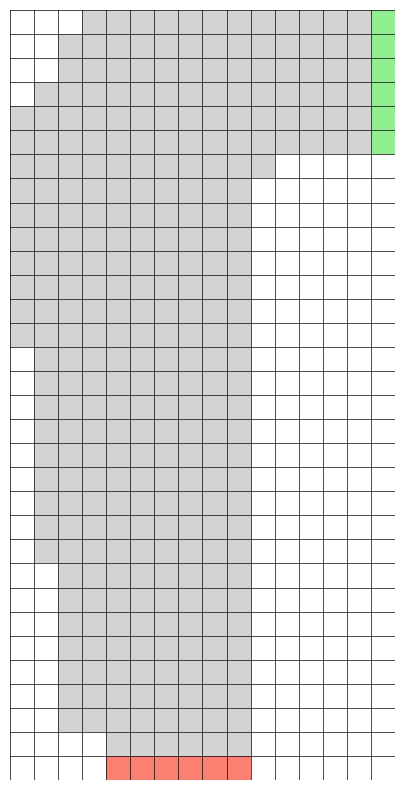

On-Policy MC Control...
Episode 0/1000000, Total Reward: 582
Episode 10000/1000000, Total Reward: 767
Episode 20000/1000000, Total Reward: 990
Episode 30000/1000000, Total Reward: 987
Episode 40000/1000000, Total Reward: 987
Episode 50000/1000000, Total Reward: 987
Episode 60000/1000000, Total Reward: 991
Episode 70000/1000000, Total Reward: 988
Episode 80000/1000000, Total Reward: 678
Episode 90000/1000000, Total Reward: 991
Episode 100000/1000000, Total Reward: 988
Episode 110000/1000000, Total Reward: 887
Episode 120000/1000000, Total Reward: 990
Episode 130000/1000000, Total Reward: 784
Episode 140000/1000000, Total Reward: 888
Episode 150000/1000000, Total Reward: 991
Episode 160000/1000000, Total Reward: 991
Episode 170000/1000000, Total Reward: 990
Episode 180000/1000000, Total Reward: 991
Episode 190000/1000000, Total Reward: 991
Episode 200000/1000000, Total Reward: 885
Episode 210000/1000000, Total Reward: 878
Episode 220000/1000000, Total Reward: 990
Episode 230000/1000000, 

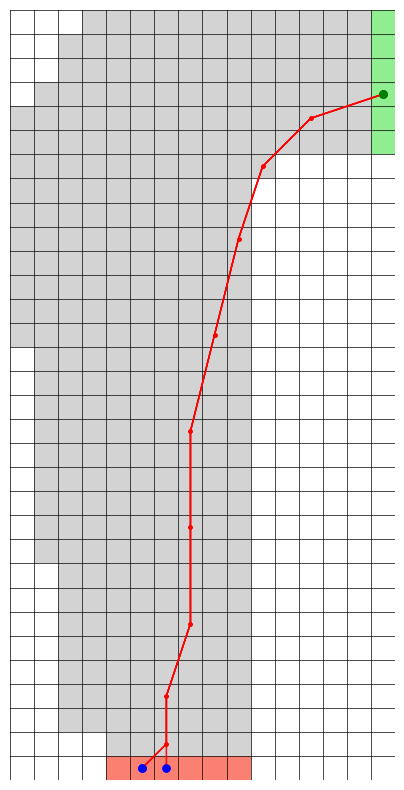

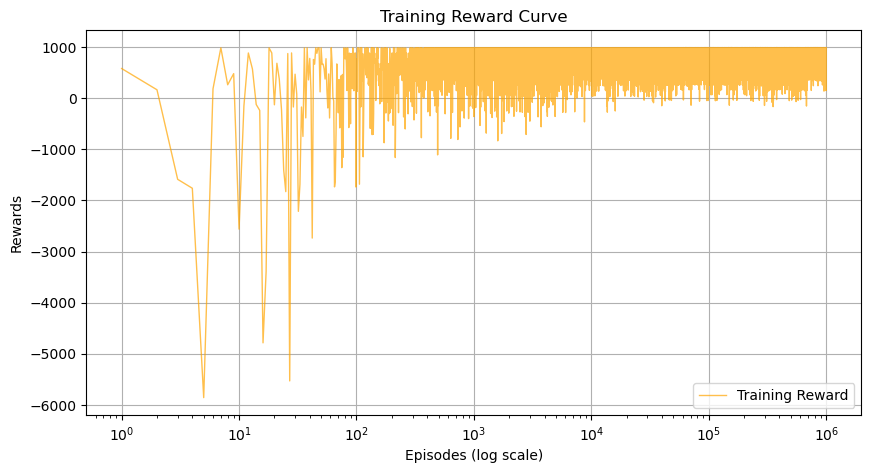

In [12]:
# test
game_m1 = racetrack_map_1()
game_m1.create_map()
game_m1.print_track()
env_m1 = racetrack(game_m1.grid, noise=0.1)

#trainning
print("On-Policy MC Control...")
on_policy_m1, q_on_m1, ep_r_m1, s_ra_m1 = on_policy_MC_ctrl(env_m1, episodes=1000000, gamma=0.9, epsilon=0.1, max_steps=5000)
print("   on_policy size =", len(on_policy_m1))

print("3) Off-Policy MC Control...")
off_policy_m1, Q_off_m1 = mc_off_policy_control(env_m1, num_episodes=10000)
print("   off_policy size =", len(off_policy_m1))


# print trajectory
print("Testing on_policy:")
# cancel the noise
env_m1.noise = 0.0

trajectories = []
for start_cell in env_m1.start_cells:

    env_m1.state = (start_cell[0], start_cell[1], 0, 0)
    traj, _ = gameplay(env_m1, policy=on_policy_m1)
    trajectories.append(traj)

# trajectory_m1, total_reward_m1 = gameplay(env_m1, on_policy_m1)
# print(f"   Steps={len(trajectory_m1)}, Reward={total_reward_m1}, FinalPos={trajectory_m1[-1]}")

# print( "Trajectory:", trajectory_m1)

print("Testing off_policy:")
traj_off_m1, r_off_m1 = gameplay(env_m1, off_policy_m1)
print(f"   Steps={len(traj_off_m1)}, Reward={r_off_m1}, FinalPos={traj_off_m1[-1]}")

# print("Trajectory:", traj_off_m1)

game_m1.print_track(trajectories)
# game_m1.print_track([traj_off_m1])
# game_m1.print_track([trajectory_m1, traj_off_m1])

#rewards curve
plot_training_curve(ep_r_m1)

#success rate
# plot_success_rate(s_ra_m1)
